# Customer Churn Analysis

**Dataset:** Telco Customer Churn (`WA_Fn-UseC_-Telco-Customer-Churn.csv`) — 7,043 customers, 21 features  
**Goal:** Identify patterns driving churn and build production-ready predictive models  
**Models:** Logistic Regression · Random Forest · XGBoost  
**Outcome:** Serialised models + scaler + feature columns used directly by `app.py`

## 1. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay,
    PrecisionRecallDisplay, ConfusionMatrixDisplay,
    precision_recall_curve
)
import xgboost as xgb
import shap

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

os.makedirs('models', exist_ok=True)
print('Libraries loaded ✓')

Libraries loaded ✓


## 2. Data Loading

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Shape: 7,043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 4. Data Cleaning

In [5]:
# TotalCharges is object dtype due to blank strings — coerce and fill
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
missing = df['TotalCharges'].isnull().sum()
print(f'NaN values in TotalCharges after coercion: {missing}')

NaN values in TotalCharges after coercion: 11


In [6]:
# Fill the 11 new-customer rows (tenure=0) with MonthlyCharges × tenure (= 0)
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'] * df['tenure'])
print(f'Remaining NaN after fill: {df["TotalCharges"].isnull().sum()}')

Remaining NaN after fill: 0


In [7]:
# Confirm no missing values anywhere
print(df.isnull().sum()[df.isnull().sum() > 0])
print('No missing values ✓')

Series([], dtype: int64)
No missing values ✓


## 5. Exploratory Data Analysis (EDA)

### 5.1 Churn Distribution

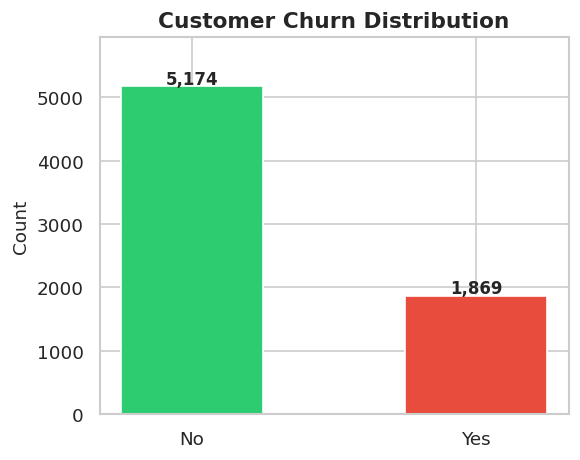

Churn rate: 26.5%


In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
churn_counts = df['Churn'].value_counts()
bars = ax.bar(churn_counts.index, churn_counts.values,
              color=['#2ecc71', '#e74c3c'], width=0.5, edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
            f'{bar.get_height():,}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Customer Churn Distribution', fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, churn_counts.max() * 1.15)
plt.tight_layout()
plt.savefig('01_churn_distribution.png', bbox_inches='tight')
plt.show()
print(f'Churn rate: {(df["Churn"]=="Yes").mean()*100:.1f}%')

### 5.2 Numerical Features by Churn

In [9]:
df.groupby('Churn')[['MonthlyCharges', 'TotalCharges', 'tenure']].describe()

MonthlyCharges                                                    \
               count       mean        std    min    25%     50%   75%   
Churn                                                                    
No            5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4   
Yes           1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2   

              TotalCharges               ...                    tenure  \
          max        count         mean  ...      75%      max   count   
Churn                                    ...                             
No     118.75       5174.0  2549.911442  ...  4262.85  8672.45  5174.0   
Yes    118.35       1869.0  1531.796094  ...  2331.30  8684.80  1869.0   

                                                          
            mean        std  min   25%   50%   75%   max  
Churn                                                     
No     37.569965  24.113777  0.0  15.0  38.0  61.0  72.0  
Yes    17.979133  19.531123  1.0   2.0  10.0  29.0  72.0  

[2 rows x 24 columns]

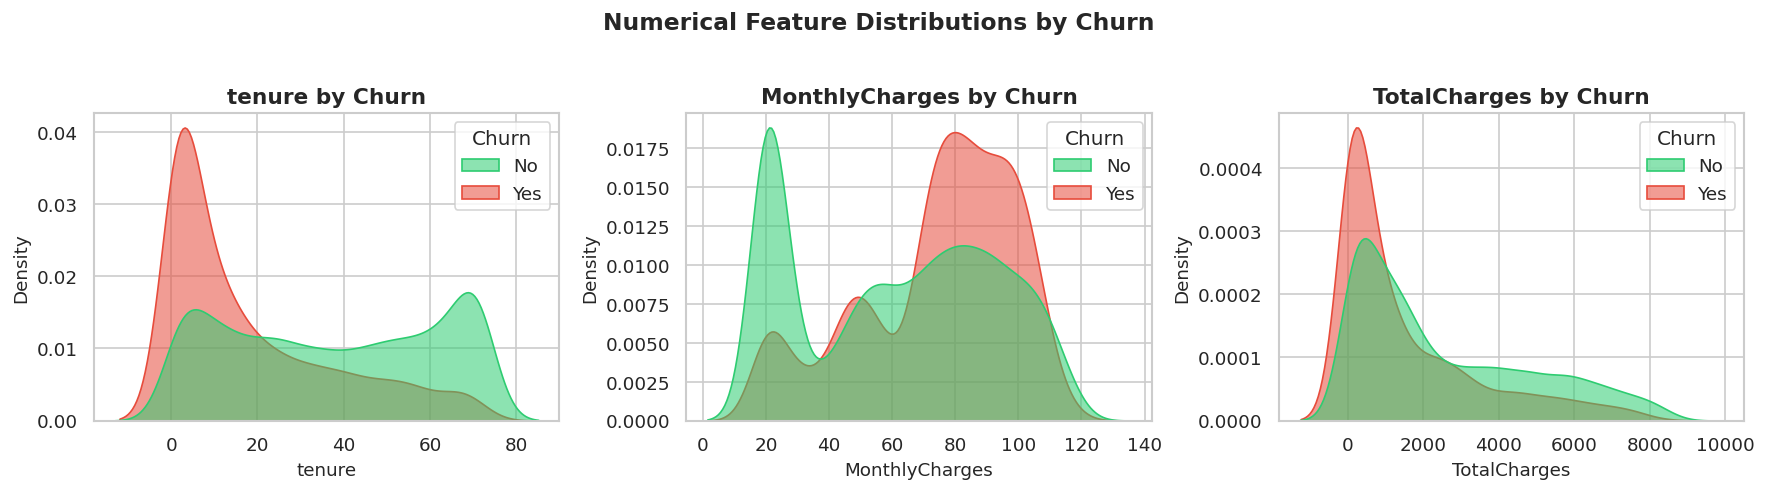

In [10]:
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feature in zip(axes, num_features):
    sns.kdeplot(data=df, x=feature, hue='Churn', fill=True,
                common_norm=False, alpha=0.55,
                palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, ax=ax)
    ax.set_title(f'{feature} by Churn', fontweight='bold')

plt.suptitle('Numerical Feature Distributions by Churn', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('02_kde_numerical.png', bbox_inches='tight')
plt.show()

**Key observations:**
- Short-tenure customers churn far more often
- Churned customers have **higher** MonthlyCharges on average
- TotalCharges is lower for churned customers (because tenure is shorter)

### 5.3 Key Categorical Features

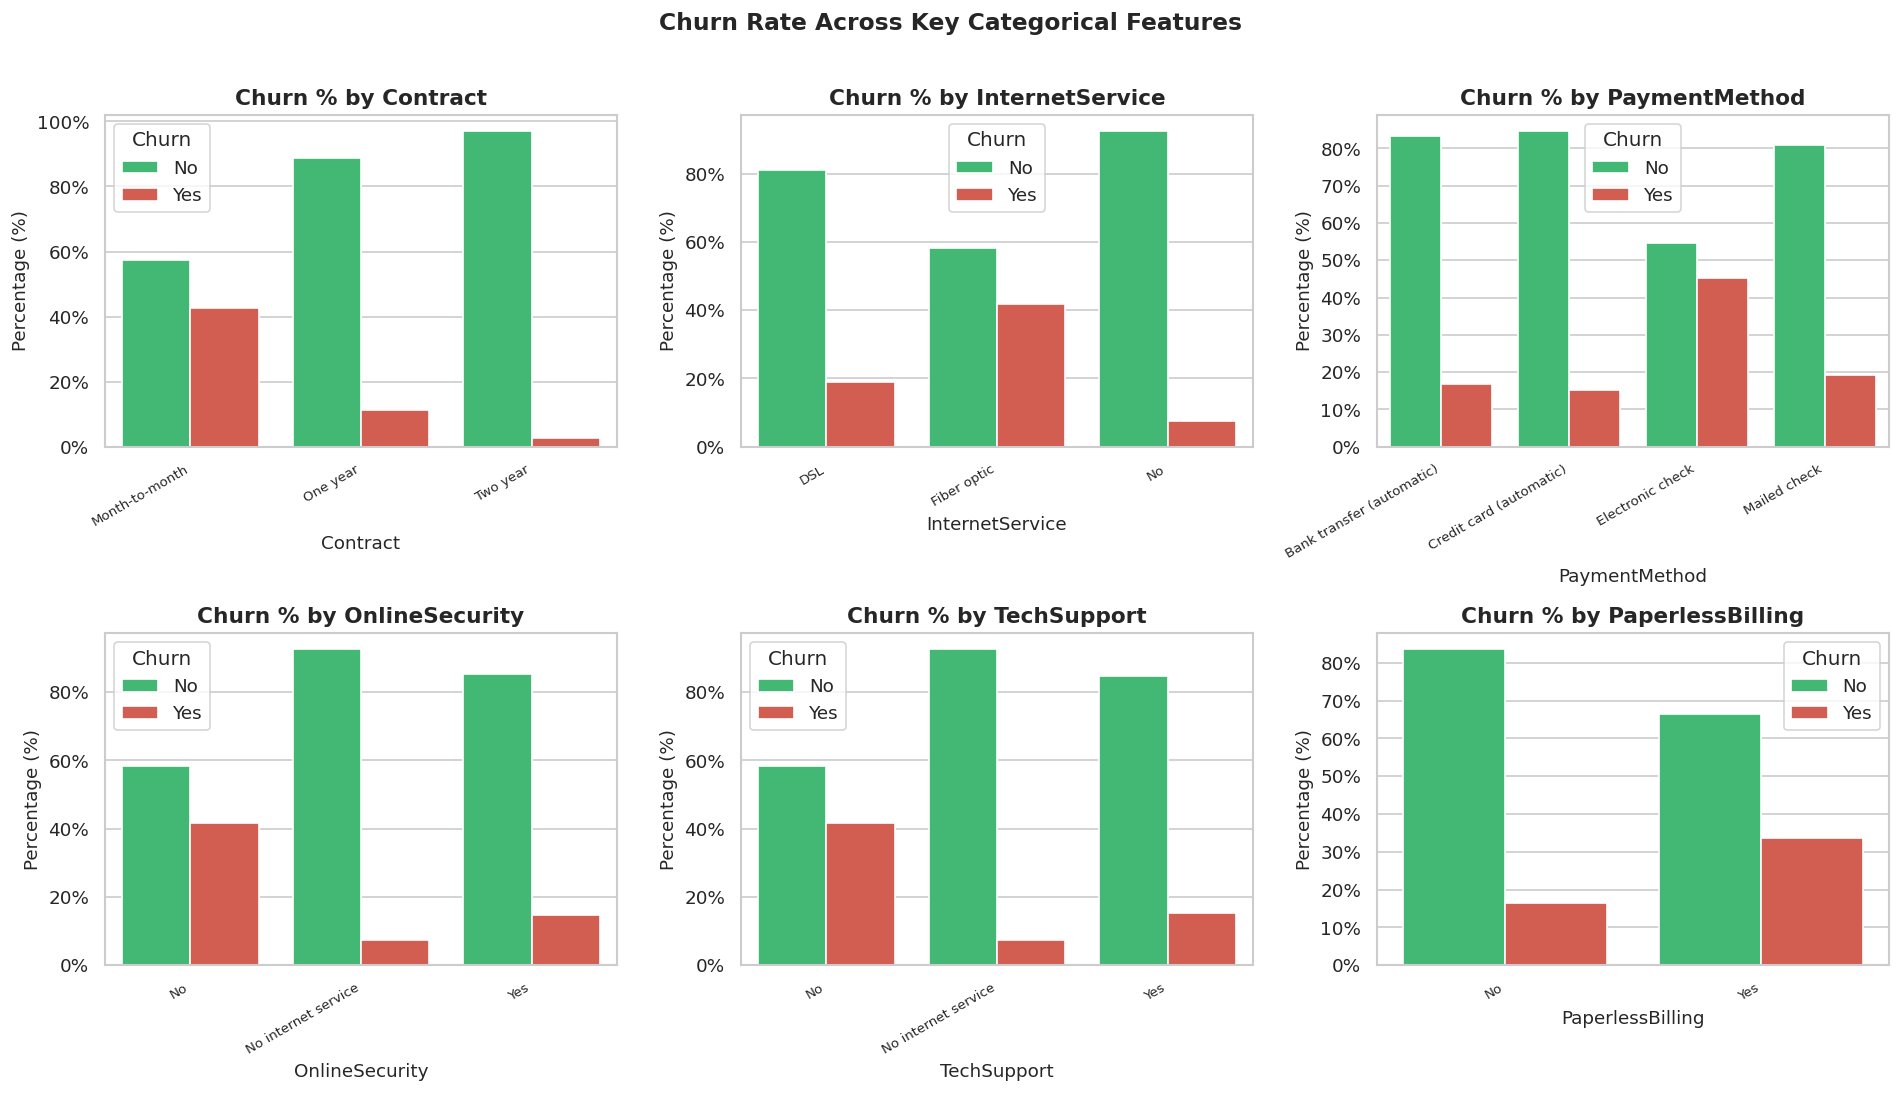

In [11]:
key_cats = ['Contract', 'InternetService', 'PaymentMethod',
            'OnlineSecurity', 'TechSupport', 'PaperlessBilling']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, feature in zip(axes.flatten(), key_cats):
    counts = df.groupby([feature, 'Churn']).size().unstack(fill_value=0)
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    pct_long = pct.reset_index().melt(id_vars=feature, value_vars=['No', 'Yes'],
                                       var_name='Churn', value_name='Percentage')
    sns.barplot(x=feature, y='Percentage', hue='Churn', data=pct_long,
                palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, ax=ax)
    ax.set_title(f'Churn % by {feature}', fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Percentage (%)')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.suptitle('Churn Rate Across Key Categorical Features', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('03_categorical_churn.png', bbox_inches='tight')
plt.show()

### 5.4 Correlation Heatmap

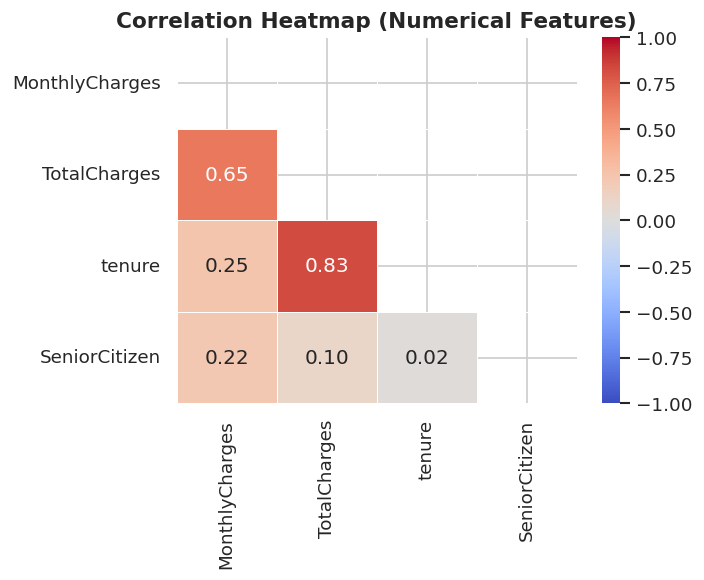

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
corr = df[['MonthlyCharges', 'TotalCharges', 'tenure', 'SeniorCitizen']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', mask=mask,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap (Numerical Features)', fontweight='bold')
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', bbox_inches='tight')
plt.show()

**Note:** TotalCharges is highly correlated with tenure (r ≈ 0.83) — expected since TotalCharges ≈ MonthlyCharges × tenure. We keep all three as the model benefits from the interaction signal.


## 6. Feature Engineering

> **Design decision:** All feature engineering is applied to a **single `df_model` copy** and the resulting column list is saved as `models/feature_columns.pkl`. The Streamlit app **must replicate this exact pipeline** — any mismatch causes silent wrong predictions or crashes.

In [13]:
df_model = df.copy()

In [14]:
# --- Target encoding ---
df_model['Churn'] = (df_model['Churn'] == 'Yes').astype(int)

In [15]:
# --- Binary label encoding ---
le = LabelEncoder()
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ('customerID',)]

binary_cols = [c for c in cat_cols if df_model[c].nunique() == 2]
for col in binary_cols:
    df_model[col] = le.fit_transform(df_model[col])

In [16]:
# --- One-hot encode multi-category columns ---
multi_cat_cols = [c for c in cat_cols if df_model[c].nunique() > 2]
print(f'One-hot encoding: {multi_cat_cols}')
df_model = pd.get_dummies(df_model, columns=multi_cat_cols)

One-hot encoding: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [17]:
# --- Tenure bins (ordinal business insight) ---
df_model['tenure_group'] = pd.cut(
    df_model['tenure'],
    bins=[0, 12, 24, 48, 60, 72],
    labels=['0-12m', '13-24m', '25-48m', '49-60m', '61-72m']
)
df_model = pd.get_dummies(df_model, columns=['tenure_group'])

In [18]:
# Convert all bool columns to int (important for XGBoost compatibility)
bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

In [19]:
print(f'Final feature set: {df_model.shape[1] - 2} features (excl. customerID + Churn)')

Final feature set: 45 features (excl. customerID + Churn)


## 7. Train / Validation / Test Split

In [20]:
X = df_model.drop(columns=['customerID', 'Churn'])
y = df_model['Churn']

# 70 / 10 / 20 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp)

print(f'Train : {len(X_train):,} | Val : {len(X_val):,} | Test : {len(X_test):,}')
print(f'Churn rate → Train: {y_train.mean()*100:.1f}% | '
      f'Val: {y_val.mean()*100:.1f}% | Test: {y_test.mean()*100:.1f}%')

Train : 4,930 | Val : 704 | Test : 1,409
Churn rate → Train: 26.5% | Val: 26.6% | Test: 26.5%


In [21]:
# Scale for Logistic Regression  (fit ONLY on X_train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Numpy arrays for XGBoost (avoids feature-name warnings across versions)
X_train_np = X_train.to_numpy(dtype=float)
X_val_np   = X_val.to_numpy(dtype=float)
X_test_np  = X_test.to_numpy(dtype=float)

print('Scaler fitted and arrays prepared ✓')

Scaler fitted and arrays prepared ✓


## 8. Logistic Regression

In [22]:
lr_params = {
    'C':       [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver':  ['liblinear']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42),
    lr_params, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
lr_grid.fit(X_train_scaled, y_train)
lr_model = lr_grid.best_estimator_

print(f'Best params : {lr_grid.best_params_}')
print(f'Best CV AUC : {lr_grid.best_score_:.4f}')

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params : {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV AUC : 0.8463


In [23]:
for split, X_s, y_s in [('Train', X_train_scaled, y_train),
                         ('Val',   X_val_scaled,   y_val),
                         ('Test',  X_test_scaled,  y_test)]:
    prob = lr_model.predict_proba(X_s)[:, 1]
    pred = lr_model.predict(X_s)
    auc  = roc_auc_score(y_s, prob)
    print(f'\n── Logistic Regression | {split} Set  (AUC={auc:.4f}) ──')
    print(classification_report(y_s, pred))
    print(confusion_matrix(y_s, pred))


── Logistic Regression | Train Set  (AUC=0.8493) ──
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      3622
           1       0.52      0.80      0.63      1308

    accuracy                           0.75      4930
   macro avg       0.71      0.77      0.72      4930
weighted avg       0.81      0.75      0.76      4930

[[2643  979]
 [ 260 1048]]

── Logistic Regression | Val Set  (AUC=0.8280) ──
              precision    recall  f1-score   support

           0       0.91      0.70      0.79       517
           1       0.49      0.80      0.61       187

    accuracy                           0.73       704
   macro avg       0.70      0.75      0.70       704
weighted avg       0.80      0.73      0.74       704

[[363 154]
 [ 37 150]]

── Logistic Regression | Test Set  (AUC=0.8499) ──
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.

## 9. Random Forest

In [24]:
rf_params = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [6, 10, None],
    'min_samples_leaf': [3, 5, 10],
    'max_features':     ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    rf_params, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
rf_grid.fit(X_train, y_train)
rf_model = rf_grid.best_estimator_

print(f'Best params : {rf_grid.best_params_}')
print(f'Best CV AUC : {rf_grid.best_score_:.4f}')

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params : {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 10, 'n_estimators': 100}
Best CV AUC : 0.8495


In [25]:
for split, X_s, y_s in [('Train', X_train, y_train),
                         ('Val',   X_val,   y_val),
                         ('Test',  X_test,  y_test)]:
    prob = rf_model.predict_proba(X_s)[:, 1]
    pred = rf_model.predict(X_s)
    auc  = roc_auc_score(y_s, prob)
    print(f'\n── Random Forest | {split} Set  (AUC={auc:.4f}) ──')
    print(classification_report(y_s, pred))


── Random Forest | Train Set  (AUC=0.8973) ──
              precision    recall  f1-score   support

           0       0.93      0.80      0.86      3622
           1       0.60      0.83      0.70      1308

    accuracy                           0.81      4930
   macro avg       0.76      0.82      0.78      4930
weighted avg       0.84      0.81      0.82      4930


── Random Forest | Val Set  (AUC=0.8325) ──
              precision    recall  f1-score   support

           0       0.91      0.74      0.82       517
           1       0.53      0.80      0.64       187

    accuracy                           0.76       704
   macro avg       0.72      0.77      0.73       704
weighted avg       0.81      0.76      0.77       704


── Random Forest | Test Set  (AUC=0.8481) ──
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1035
           1       0.55      0.78      0.65       374

    accuracy                           0.77 

## 10. XGBoost

> **Important:** XGBoost is trained on numpy arrays (`X_train_np`) derived from the same pandas columns. The app's `prepare_input()` must produce the **same column order** as `X_train.columns` before converting to numpy — this is enforced by `df.reindex(columns=feature_columns)`.

In [26]:
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_params = {
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.01, 0.05, 0.1],
    'n_estimators':     [200, 300, 500],
    'subsample':        [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8]
}

xgb_grid = GridSearchCV(
    xgb.XGBClassifier(
        scale_pos_weight=neg_pos_ratio,
        eval_metric='logloss',
        random_state=42
    ),
    xgb_params, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
# ── Train on numpy arrays to avoid XGBoost/pandas feature-name version conflicts
xgb_grid.fit(X_train_np, y_train)
xgb_model = xgb_grid.best_estimator_

print(f'Best params : {xgb_grid.best_params_}')
print(f'Best CV AUC : {xgb_grid.best_score_:.4f}')

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params : {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.7}
Best CV AUC : 0.8502


In [27]:
for split, X_s, y_s in [('Train', X_train_np, y_train),
                         ('Val',   X_val_np,   y_val),
                         ('Test',  X_test_np,  y_test)]:
    prob = xgb_model.predict_proba(X_s)[:, 1]
    pred = xgb_model.predict(X_s)
    auc  = roc_auc_score(y_s, prob)
    print(f'\n── XGBoost | {split} Set  (AUC={auc:.4f}) ──')
    print(classification_report(y_s, pred))


── XGBoost | Train Set  (AUC=0.8675) ──
              precision    recall  f1-score   support

           0       0.92      0.73      0.82      3622
           1       0.53      0.83      0.65      1308

    accuracy                           0.76      4930
   macro avg       0.73      0.78      0.73      4930
weighted avg       0.82      0.76      0.77      4930


── XGBoost | Val Set  (AUC=0.8386) ──
              precision    recall  f1-score   support

           0       0.93      0.72      0.81       517
           1       0.52      0.84      0.64       187

    accuracy                           0.75       704
   macro avg       0.72      0.78      0.73       704
weighted avg       0.82      0.75      0.76       704


── XGBoost | Test Set  (AUC=0.8503) ──
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro

## 11. Model Comparison

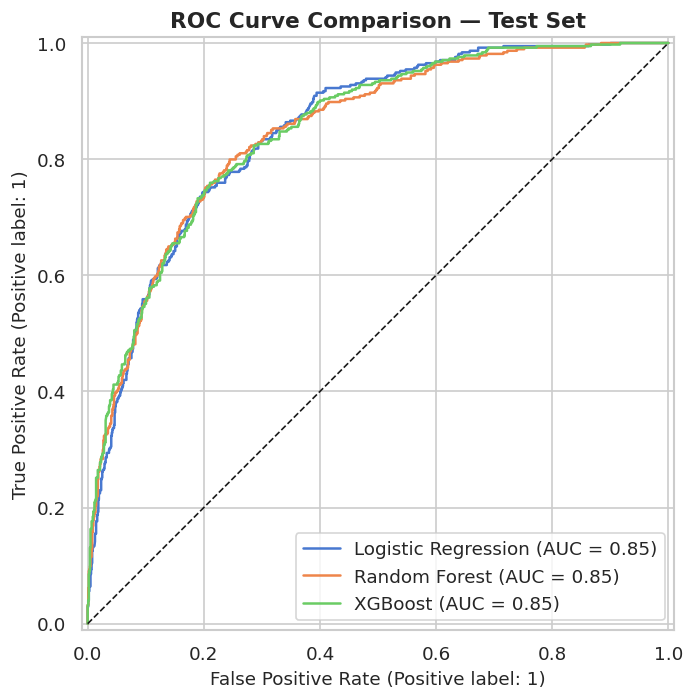

In [28]:
# ── ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(lr_model,  X_test_scaled, y_test,
                                name='Logistic Regression', ax=ax)
RocCurveDisplay.from_estimator(rf_model,  X_test,        y_test,
                                name='Random Forest',       ax=ax)
RocCurveDisplay.from_estimator(xgb_model, X_test_np,     y_test,
                                name='XGBoost',             ax=ax)
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_title('ROC Curve Comparison — Test Set', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('05_roc_comparison.png', bbox_inches='tight')
plt.show()

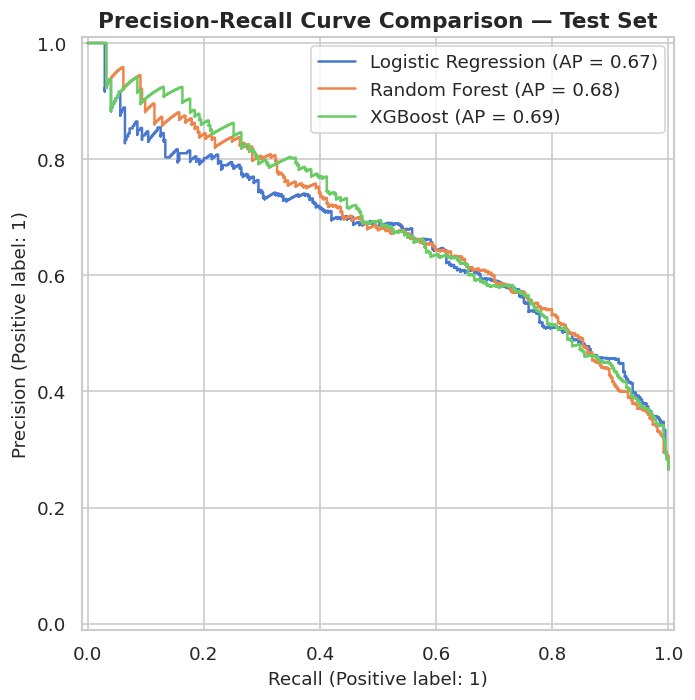

In [29]:
# ── Precision-Recall Curves
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_estimator(lr_model,  X_test_scaled, y_test,
                                       name='Logistic Regression', ax=ax)
PrecisionRecallDisplay.from_estimator(rf_model,  X_test,        y_test,
                                       name='Random Forest',       ax=ax)
PrecisionRecallDisplay.from_estimator(xgb_model, X_test_np,     y_test,
                                       name='XGBoost',             ax=ax)
ax.set_title('Precision-Recall Curve Comparison — Test Set', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('06_pr_comparison.png', bbox_inches='tight')
plt.show()

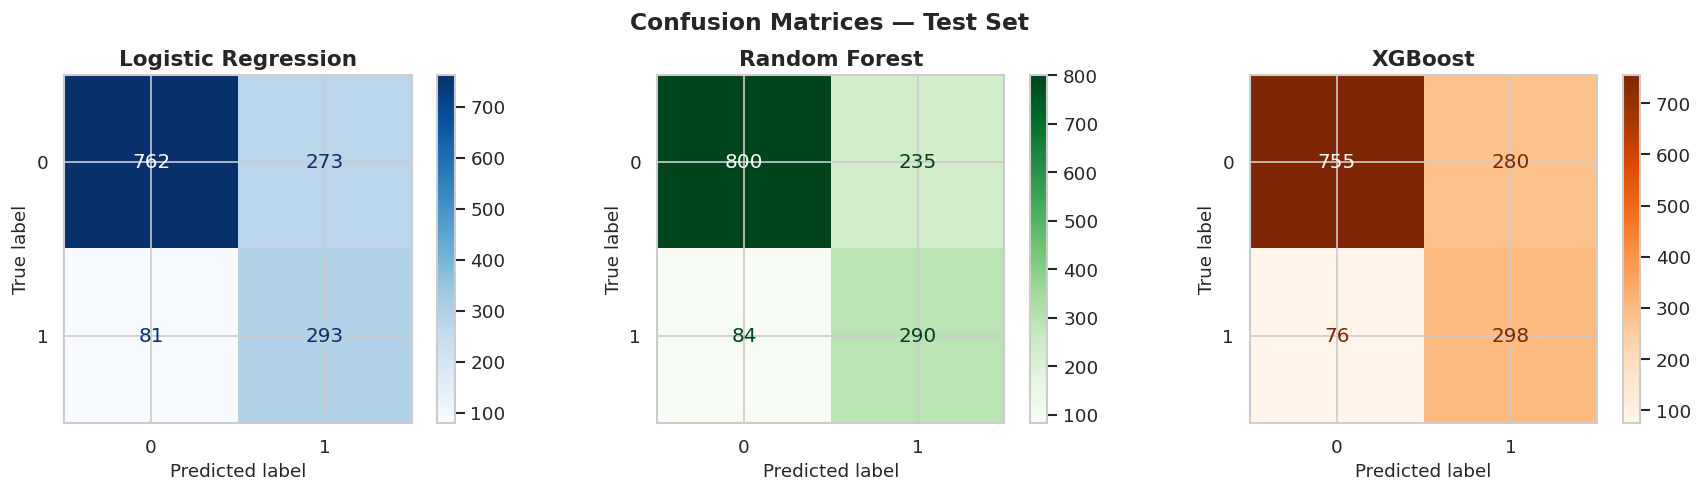

In [30]:
# ── Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model, X_s), cmap in zip(
    axes,
    [('Logistic Regression', lr_model,  X_test_scaled),
     ('Random Forest',       rf_model,  X_test),
     ('XGBoost',             xgb_model, X_test_np)],
    ['Blues', 'Greens', 'Oranges']
):
    ConfusionMatrixDisplay.from_estimator(model, X_s, y_test, cmap=cmap, ax=ax)
    ax.set_title(f'{name}', fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('07_confusion_matrices.png', bbox_inches='tight')
plt.show()

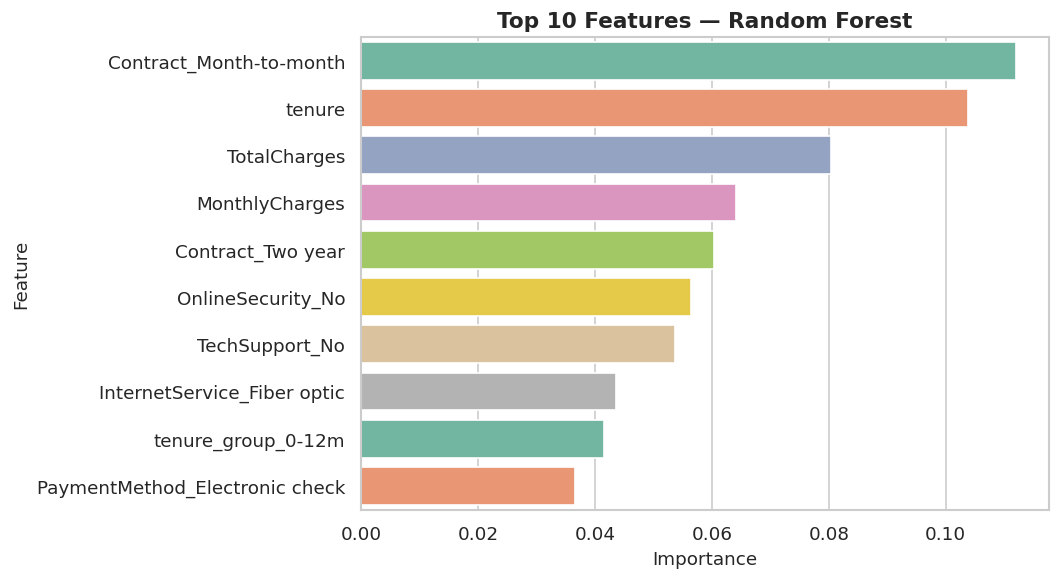

In [31]:
# ── Feature Importance (Random Forest)
feat_imp = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

top10 = feat_imp.head(10)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x='Importance', y='Feature', data=top10, palette='Set2', ax=ax)
ax.set_title('Top 10 Features — Random Forest', fontweight='bold')
plt.tight_layout()
plt.savefig('08_feature_importance.png', bbox_inches='tight')
plt.show()

In [32]:
# ── Summary Table
lr_auc  = roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:, 1])
rf_auc  = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test_np)[:, 1])

summary = pd.DataFrame({
    'Model':    ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Test AUC': [f'{lr_auc:.4f}',       f'{rf_auc:.4f}', f'{xgb_auc:.4f}'],
})
print('\n' + '='*40)
print('        MODEL COMPARISON SUMMARY')
print('='*40)
print(summary.to_string(index=False))


        MODEL COMPARISON SUMMARY
              Model Test AUC
Logistic Regression   0.8499
      Random Forest   0.8481
            XGBoost   0.8503


## 12. Threshold Tuning (XGBoost)

Default 0.5 threshold optimises accuracy, not recall. For churn the business cost of a missed churner (false negative) is typically higher, so we tune the threshold to achieve ≥ 80% recall.

In [33]:
probs_val = xgb_model.predict_proba(X_val_np)[:, 1]
precision_arr, recall_arr, thresh_arr = precision_recall_curve(y_val, probs_val)

# First threshold where recall >= 0.80
idx = np.argmax(recall_arr >= 0.80)
optimal_threshold_xgb = float(thresh_arr[idx])
print(f'XGBoost optimal threshold (recall≥0.80): {optimal_threshold_xgb:.4f}')

thresholds_dict = {
    'XGBoost':             optimal_threshold_xgb,
    'Random Forest':       0.40,
    'Logistic Regression': 0.45
}

joblib.dump(thresholds_dict, 'models/thresholds.pkl')
print('Thresholds saved ✓')

XGBoost optimal threshold (recall≥0.80): 0.0184
Thresholds saved ✓


## 13. SHAP Analysis

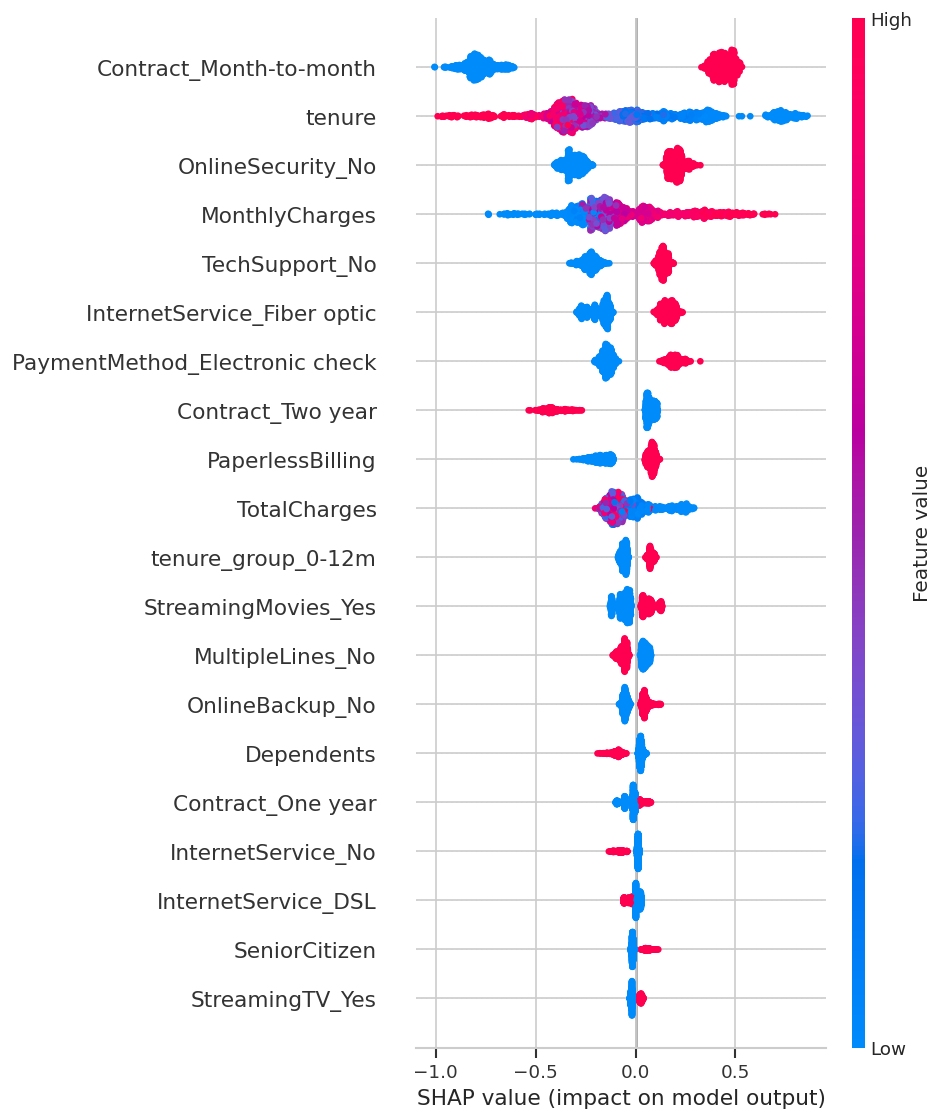

SHAP explainer saved ✓


In [34]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_np)

shap.summary_plot(shap_values, X_test_np, feature_names=X_train.columns.tolist(),
                  show=True)

# Save explainer for the Streamlit app
joblib.dump(explainer, 'models/shap_explainer.pkl')
print('SHAP explainer saved ✓')

## 14. Save All Artefacts

In [35]:
joblib.dump(lr_model,                  'models/logistic_model.pkl')
joblib.dump(rf_model,                  'models/random_forest_model.pkl')
joblib.dump(xgb_model,                 'models/xgb_model.pkl')
joblib.dump(scaler,                    'models/scaler.pkl')
joblib.dump(X_train.columns.tolist(),  'models/feature_columns.pkl')

print('Saved artefacts:')
for f in os.listdir('models'):
    print(f'  models/{f}')

Saved artefacts:
  models/shap_explainer.pkl
  models/scaler.pkl
  models/feature_columns.pkl
  models/thresholds.pkl
  models/random_forest_model.pkl
  models/xgb_model.pkl
  models/logistic_model.pkl
